In [1]:
import numpy as np
import sys
sys.path.append("snag")
import snag
import matplotlib.pyplot as plt

In [19]:
n_sites = 6
n_part = 3 #n_sites // 2

print("Generating basis")
basis = snag.gen_basis(n_sites, n_part)
occs = np.array([[int(i) for i in s] for s in basis.keys()])
print(basis)
print(occs)

print("Generating Kinetic Hamiltonian")
t_mat = snag.kinetic_1d(basis)
print(t_mat)

print("Generating Interaction Hamiltonian")
u_mat = snag.nn_int(basis)
print(u_mat)

Generating basis
{'000111': 0, '001011': 1, '001101': 2, '001110': 3, '010011': 4, '010101': 5, '010110': 6, '011001': 7, '011010': 8, '011100': 9, '100011': 10, '100101': 11, '100110': 12, '101001': 13, '101010': 14, '101100': 15, '110001': 16, '110010': 17, '110100': 18, '111000': 19}
[[0 0 0 1 1 1]
 [0 0 1 0 1 1]
 [0 0 1 1 0 1]
 [0 0 1 1 1 0]
 [0 1 0 0 1 1]
 [0 1 0 1 0 1]
 [0 1 0 1 1 0]
 [0 1 1 0 0 1]
 [0 1 1 0 1 0]
 [0 1 1 1 0 0]
 [1 0 0 0 1 1]
 [1 0 0 1 0 1]
 [1 0 0 1 1 0]
 [1 0 1 0 0 1]
 [1 0 1 0 1 0]
 [1 0 1 1 0 0]
 [1 1 0 0 0 1]
 [1 1 0 0 1 0]
 [1 1 0 1 0 0]
 [1 1 1 0 0 0]]
Generating Kinetic Hamiltonian
[[ 0 -1  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0]
 [-1  0 -1  0 -1  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0]
 [ 0 -1  0 -1  0 -1  0  0  0  0  0  0  0  0  0 -1  0  0  0  0]
 [ 0  0 -1  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 -1  0  0  0 -1  0  0  0  0 -1  0  0  0  0  0  0 -1  0  0]
 [ 0  0 -1  0 -1  0 -1 -1  0  0  0 -1  0  0  0  0  0  0 -1  0]
 [

In [20]:
# Spinless Hubbard
snag.solve(t_mat).eigenvalues

array([-4.00000000e+00, -2.00000000e+00, -2.00000000e+00, -2.00000000e+00,
       -2.00000000e+00, -1.00000000e+00, -1.00000000e+00, -1.00000000e+00,
       -1.00000000e+00, -2.43011423e-16,  3.63087165e-16,  1.00000000e+00,
        1.00000000e+00,  1.00000000e+00,  1.00000000e+00,  2.00000000e+00,
        2.00000000e+00,  2.00000000e+00,  2.00000000e+00,  4.00000000e+00])

In [21]:
non_int = snag.NonInt1D(n_sites)
ni_spec = non_int.many_body_spectrum(n_part)

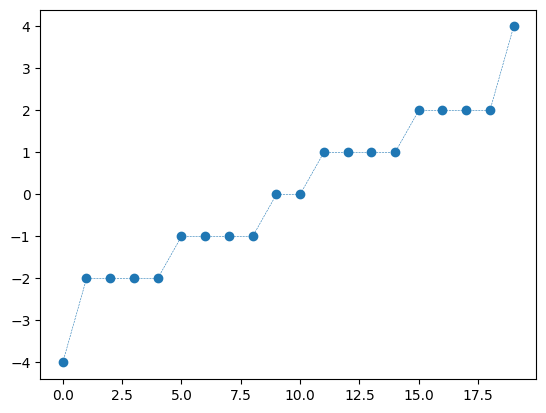

In [22]:
plt.plot(ni_spec[:20], marker='o', ls='--', lw=0.4)

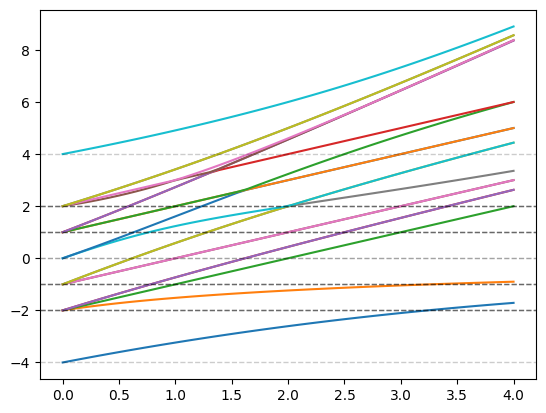

In [23]:
int_strengths = np.linspace(0., 4., 50)
eig_scan = []

for int_strength in int_strengths:
    ham = t_mat + int_strength * np.diag(u_mat)
    result = snag.solve(ham)
    eig_scan.append(result.eigenvalues)

eig_scan = np.array(eig_scan)

for e in eig_scan.T:
    plt.plot(int_strengths, e)

for e in non_int.many_body_spectrum(n_part):
    plt.axhline(y=e, c='k', ls='--', lw=1, alpha=0.2)

In [28]:
result = np.linalg.eigh(t_mat)
probs_0 = np.conj(result.eigenvectors[:, 0]) * result.eigenvectors[:, 0]
density = (occs * probs_0[:, None]).sum(0)
density


array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5])